<!-- SPDX-FileCopyrightText: 2026 Orbital Research Cluster for Celestial Applications (ORCCA) Lab, University of Colorado at Boulder -->
<!-- SPDX-License-Identifier: ISC -->
# Scarabaeus Time System (EpochArray)

---
Last revised 2026 MAY 8

## Objectives
All time information in Scarabaeus (SCB) is managed by the EpochArray class. This tutorial will cover the basics of utilizing EpochArray, demonstrating common errors that may arise, performing operations with it, and converting between the many different time systems and their representations.

## See Also
- [SPICE Time Subsystem Required Reading](https://naif.jpl.nasa.gov/pub/naif/toolkit_docs/C/req/time.html)

## Imports and Set Up

First we'll import the necessary libraries, define units, and load in supplementary data, which for this tutorial are a leapsecond kernel (LSK) and a spacecraft clock kernel (SCLK). Note that we do not furnish either yet so we can illustrate what happens if you don't have them loaded.

In [1]:
import scarabaeus as scb
import supplementary as supp

import numpy as np

# define units
sec, hr, day = scb.Units.get_units(['sec', 'hr', 'day'])

# load tutorial data
data = supp.load_data()

# NOTE: it's generally good practice to load kernels here (we'll
#       need a leapsecond kernel (LSK) for this tutorial), but to
#       illustrate EpochArray error handling, the LSK furnish will
#       be omitted until later in the tutorial

SCB supplementary data up to date.


## Creating EpochArrays
EpochArray utilizes the SPICE time subsystem to perform conversions and provide representations. For a thorough explanation of SPICE's time subsystem, see [SPICE Time Subsystem Required Reading](https://naif.jpl.nasa.gov/pub/naif/toolkit_docs/C/req/time.html).

All of these different time systems and representations can sometimes be cumbersome to track while working on a script. EpochArray is intended to alleviate some of this overhead and make working with times as simple as possible. The following section will cover the most common ways to construct an EpochArray, but for an exhaustive list, see the EpochArray documentation.

### EpochArray Error Handling
EpochArray implements a robust set of error handling to make clear why something may be failing. This section will provide examples that raise a few of these errors to illustrate common pitfalls when working with time in SCB

- **NOTE**: If an EpochArray error is raised as the result of another error deeper within SPICE, the SPICE error will also be noted at the end, e.g. `-- SPICE(UNPARSEDTIME)`.

---
#### MissingLSKError
All times in EpochArray are internally defined in Barycentric Dynamical Time (TDB), also known as Ephemeris Time (ET). This maintains consistency when performing time operations, but it also requires that a leapsecond kernel (LSK) be loaded if attempting to use to any non-uniform time representations like ISOC or CAL.

In [2]:
# make sure the kernel pool is clean
scb.SpiceManager.clear_kernels()

# uniform systems work without an LSK as long as the format is also uniform
eparr_tdb = scb.EpochArray(0.0)  # default system is TDB, default rep is NUM
print(f'** Uniform time systems/representations work without an LSK **\n{eparr_tdb}\n')

# throws error if missing leapseconds when providing non-uniform definition
try:
    scb.EpochArray('2026 JUN 01')
except Exception as e:
    print('** Providing a non-uniform time without a loaded leapsecond '
          f'kernel will raise an error **\n'
          f'{type(e).__name__}: {e}\n')
    
# or attempting to set a non-uniform representation even if the definiton is uniform
try:
    scb.EpochArray(0.0, rep = 'ISOC')
except Exception as e:
    print('** Requesting a non-uniform time representation without a loaded '
          f'leapsecond kernel will raise an error **\n'
          f'{type(e).__name__}: {e}\n')

** Uniform time systems/representations work without an LSK **
0.0 sec (TDB)

** Providing a non-uniform time without a loaded leapsecond kernel will raise an error **
SpiceNOLEAPSECONDS: 

Toolkit version: CSPICE_N0067

SPICE(NOLEAPSECONDS) --

The variable that points to the leapseconds (DELTET/DELTA_AT) could not be located in the kernel pool.  It is likely that the leapseconds kernel has not been loaded.

str2et_c --> STR2ET --> TTRANS


** Requesting a non-uniform time representation without a loaded leapsecond kernel will raise an error **
MissingLSKError: Cannot set requested time representation ISOC. The necessary leapsecond kernel (LSK) could not be located in the kernel pool. -- SPICE(MISSINGTIMEINFO)



Note that the previously failed definitions function correctly when an LSK is loaded. Generally the LSK should be included in the metakernel, but we'll load it directly here for clarity:

In [3]:
# load light second kernel
scb.SpiceManager.load_kernel(data.lsk.path)

# redo previous definitions to show that they work now
print(scb.EpochArray('2026 JUN 01'))
print(scb.EpochArray(0.0, rep = 'ISOC'))

833544000.0 sec (TDB)
2000-01-01T11:58:55.8160 (TDB)


---
#### BadTimeError
Passing epochs that formatted incorrectly or that don't exist will raise a BadTimeError:

In [4]:
# throws error if given an unrecognized format
try:
    scb.EpochArray('I AM NOT A TIME')
except Exception as e:
    print('** Providing an unrecognized time representation '
          'will raise an error **\n'
          f'{type(e).__name__}: {e}\n')

# throws error if the time doesn't make sense
try:
    scb.EpochArray('2026 FEB 50') 
except Exception as e:
    print('** Providing a valid time represntation but invalid time '
          'itself will raise an error **\n'
          f'{type(e).__name__}: {e}\n')

** Providing an unrecognized time representation will raise an error **
SpiceUNPARSEDTIME: 

Toolkit version: CSPICE_N0067

SPICE(UNPARSEDTIME) --

The input string contains an unrecognizable substring beginning at the character marked by <I>: "<I> AM NOT A TIME TDB"

str2et_c --> STR2ET


** Providing a valid time represntation but invalid time itself will raise an error **
SpiceBADTIMESTRING: 

Toolkit version: CSPICE_N0067

SPICE(BADTIMESTRING) --

The day of the month specified for the month of February was 5.00E+01.  For February the day must be at least 1.0D0 and less than 2.9E+01.

str2et_c --> STR2ET




---
#### SCLKErorr
The last error we'll cover occurs when defining spacecraft clock (SCLK) epochs without a set of clock coefficients loaded in the kernel pool via a .tscn file. In order to match the epoch to the spacecraft's clock, we'll also need to provide a spacecraft ID:

In [5]:
# make sure the kernel pool is clean (and reload LSK again since we cleared it)
scb.SpiceManager.clear_kernels()
scb.SpiceManager.load_kernel(data.lsk.path)

# throws error if missing SCLK kernel and SC ID
try:
    scb.EpochArray(100000, sys = 'SCLK', sc_id = -64)  # OSIRIS-REx ID
except Exception as e:
    print('** Attempting to define an epoch in SCLK without an SCLK '
          'kernel loaded will raise an error **\n'
          f'{type(e).__name__}: {e}\n')

** Attempting to define an epoch in SCLK without an SCLK kernel loaded will raise an error **
SpiceKERNELVARNOTFOUND: 

Toolkit version: CSPICE_N0067

SPICE(KERNELVARNOTFOUND) --
The Variable Was not Found in the Kernel Pool.
Kernel variable SCLK_DATA_TYPE_64 was not found in the kernel pool.

sct2e_c --> SCT2E --> SCTYPE --> SCTY01




Just like for the LSK, loading an SCLK kernel will allow the previously failed definitions to pass:

In [6]:
# load spacecraft clock kernel
scb.SpiceManager.load_kernel(data.OREx_sclk.path)

# redo previously failed definitions and see that they work
print(scb.EpochArray(100000, sys = 'SCLK', sc_id = -64))

100000.0 unitless (SCLK)


### Array Functionality
EpochArray fully supports scalar and array-like definitions:

In [7]:
# use the same epoch for simplicity
time_str   = '2026 JUN 01 00:00:00.000'

# define and print different definition shapes
eparr_sclr = scb.EpochArray(time_str)                         # scalar
eparr_vec  = scb.EpochArray([time_str, time_str, time_str])   # vector (1D array)
eparr_mat  = scb.EpochArray(np.array([[time_str, time_str],   # matrix (nD array)
                                        [time_str, time_str]]))

for eparr in [eparr_sclr, eparr_vec, eparr_mat]:
    print(eparr)

833544000.0 sec (TDB)
[8.33544e+08 8.33544e+08 8.33544e+08] [sec ... sec] (TDB)
[[8.33544e+08 8.33544e+08]
 [8.33544e+08 8.33544e+08]]  [sec ... sec]] (TDB)


Additionally, instead of manually creating every entry in a vector of times, use ``EpochArray.interval()``. This function supports two different interval construction methods, one that defines the interval using a given time step `dt`, and the other where it defines the interval using a given number of total epochs `n_epochs`. Both are shown below:

In [8]:
# two day interval with points every 12 hours
epochs = scb.EpochArray.interval(start = '2026 JUN 01', end = '2026 JUN 03',
                                   dt = scb.ArrayWUnits(12, hr),
                                   sys = 'TDB', rep = 'CAL')
dur = epochs.duration(units = day)  # can also get the duration sequential times
print(f'** Step-defined epoch interval with duration {dur}:\n{epochs}')

# two day interval with 3 total epochs
epochs = scb.EpochArray.interval(start = '2026 JUN 01', end = '2026 JUN 03',
                                   n_epochs = 3, sys = 'TT', rep = 'CAL')
dur = epochs.duration(units = day)
print(f'\n** Count-defined epoch interval with duration {dur}:\n{epochs}')

** Step-defined epoch interval with duration 1.5 day:
['2026 MAY 31 23:58:50.815' '2026 JUN 01 11:58:50.815'
 '2026 JUN 01 23:58:50.815' '2026 JUN 02 11:58:50.815'] (TDB)


TypeError: String input not supported for TT.

Notice that the step defined interval is a half open interval [start, end) while the count defined interval is a closed interval [start, end].

## EpochArray Operations
Can only add time to an Epocharray. Can only subtract time or another EpochArray from an EpochArray:

In [9]:
a = scb.EpochArray('2026 JUN 01', rep = 'JDTDB')
b = scb.EpochArray('2026 JUN 08', rep = 'JDTDB')

# add time to an epoch
a_plus_1_day = a + scb.ArrayWUnits(1, day)
print(f'a = {a}')
print(f'a + 1 day = {a_plus_1_day}\n')

# subtract time from an epoch
a_minus_1_day = a - scb.ArrayWUnits(1, day)
print(f'a = {a}')
print(f'a - 1 day = {a_minus_1_day}\n')

# subtract an epoch from an epoch to get a time
b_minus_a = b - a
print(f'a = {a}, b = {b}')
print(f'b - a = {b_minus_a.convert_to(day)}')

a = 2461192.5 (TDB)
a + 1 day = 2461193.5 (TDB)

a = 2461192.5 (TDB)
a - 1 day = 2461191.5 (TDB)

a = 2461192.5 (TDB), b = 2461199.5 (TDB)
b - a = 7.0 day


## Converting Between EpochArrays
Can perform conersions between systems and representaitons using `.to()`:

In [10]:
eparr_tdb_cal = scb.EpochArray('2000 JAN 01 12:00:00.000')

# convert to new system
eparr_gps_cal = eparr_tdb_cal.to(sys = 'GPS')
print(f'{eparr_tdb_cal} = {eparr_gps_cal}')

# change representation
eparr_gps_num = eparr_gps_cal.to(rep = 'NUM')
print(f'{eparr_gps_cal} = {eparr_gps_num}')

# can do both at the same time as well
epa_tai_jdutc = eparr_tdb_cal.to(sys = 'TAI', rep = 'JDUTC')
print(f'{eparr_tdb_cal} = {epa_tai_jdutc}')

0.0 sec (TDB) = -51.18392726322383 sec (GPS)
-51.18392726322383 sec (GPS) = -51.18392726322383 (GPS)
0.0 sec (TDB) = JD 2451544.9992571 (TAI)


Finally, as an easy reference, we'll create a table of all the possible time systems and representations. We'll pass the June 1st, 2026 EpochArray we've been using to a supplementary plotting function that will loop through each time system and display all of its representations along a row of the table.

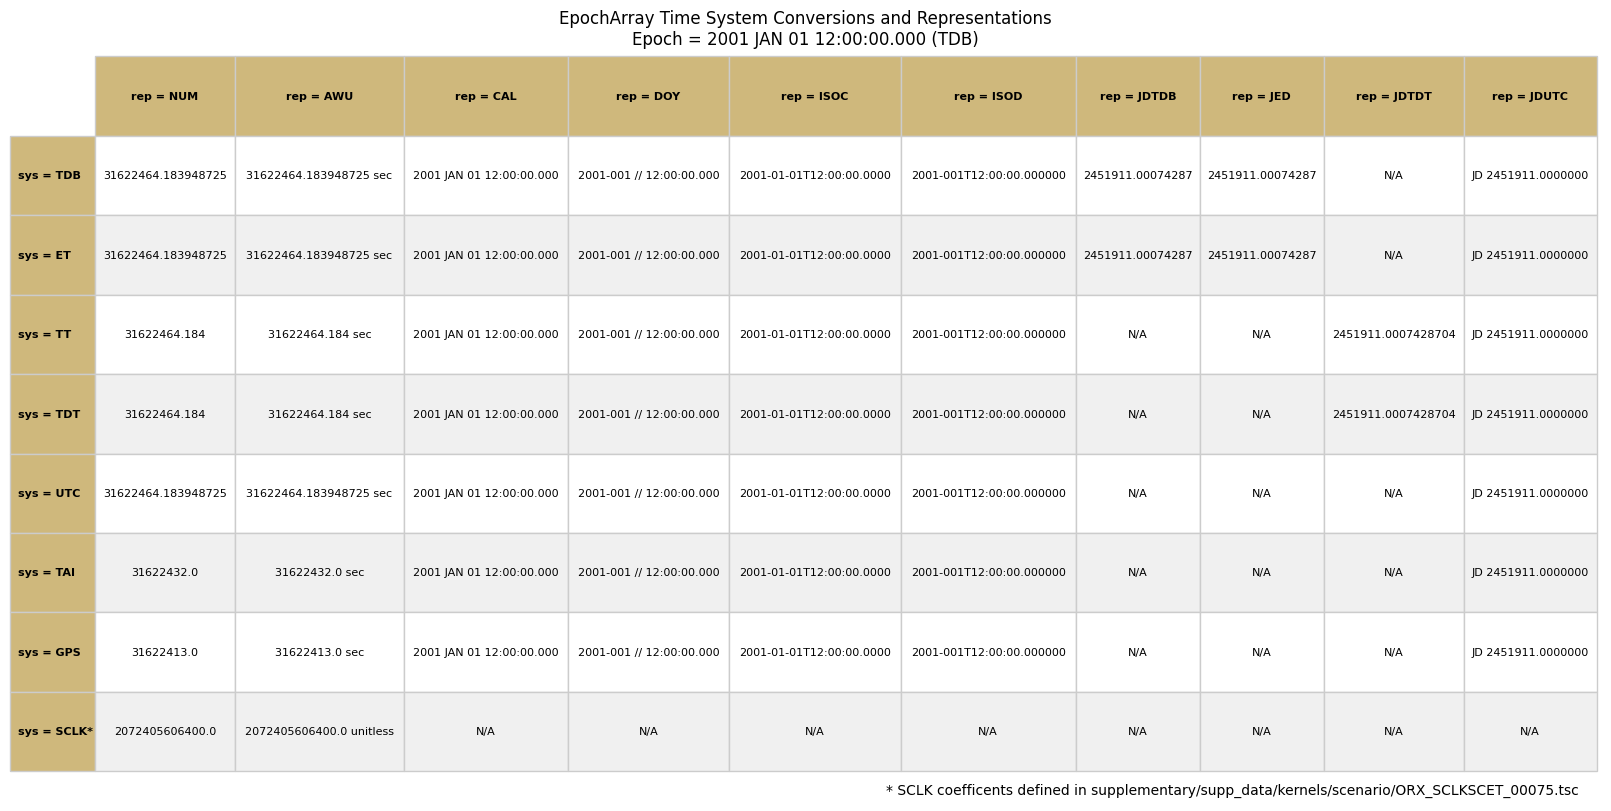

In [11]:
eparr_w_sc_id = scb.EpochArray(31622464.183948725, sys = 'TDB', sc_id = -64)
supp.plotting.plot_epocharray_table(eparr_w_sc_id, data.OREx_sclk.path)

We can see that we've checked the synonym systems like TDB and ET, as well as the sibling representations like NUM and AWU, so there will be a few identical rows and columns, but this is a good visual for all of the different combinations possible within EpochArray. Notice that plotting function has omitted representations that are are undefined for different systems, for example a JTDB representation of a TAI epoch.